# Real Data Performance

This notebook compares the performance of the EM approach to LOOCV approach using real-world datasets.

## Preview Experiment

In [ ]:
import numpy as np
import pandas as pd

from fastridge import RidgeEM, RidgeLOOCV
from experiments import Experiment
from journal2026 import (
    JOURNAL2026_TRAIN_SIZES,
    JOURNAL2026_D1_PREVIEW, JOURNAL2026_D2_PREVIEW, JOURNAL2026_D3_PREVIEW,
    JOURNAL2026_D1_REGULAR, JOURNAL2026_D1_LARGE,
    JOURNAL2026_D2_REGULAR, JOURNAL2026_D2_LARGE,
    JOURNAL2026_D3_REGULAR,
    JOURNAL2026_ESTIMATORS, JOURNAL2026_EST_NAMES,
)

exp = Experiment(
    JOURNAL2026_D1_PREVIEW, JOURNAL2026_ESTIMATORS,
    reps=10, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D1_PREVIEW],
    seed=123,
    est_names=JOURNAL2026_EST_NAMES).run(ignore_cache=True)
print()

In [2]:
def stat_mean(exp, stat_name, est_name, problem_idx):
    j = exp.est_names.index(est_name)
    return np.nanmean(getattr(exp, stat_name + '_')[:, problem_idx, 0, j])

rows = []
for i, problem in enumerate(exp.problems):
    em_time = stat_mean(exp, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp, 'prediction_r2', est, i) for est in exp.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp.ns[i, 0])
    row['n:p']      = int(exp.ns[i, 0]) / stat_mean(exp, 'number_of_features', 'EM', i)
    rows.append(row)
pd.DataFrame(rows).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed-Up,p,n_train,n:p
0,abalone,Rings,0.52,0.52,0.52,8.56,9.0,2923,324.78
1,airfoil,scaled-sound-pressure,0.50,0.50,0.50,7.09,5.0,1052,210.40
2,concrete,Concrete compressive strength,0.61,0.61,0.61,6.47,8.0,721,90.12
6,student,"G1, G2, G3",0.28,0.28,0.28,4.24,39.0,454,11.64
5,forest,area,-0.03,-0.03,-0.10,0.97,26.2,361,13.78
3,diabetes,target,0.49,0.49,0.49,4.96,10.0,309,30.90
7,yacht,Residuary_resistance,0.62,0.62,0.62,5.43,6.0,215,35.83
8,automobile,price,0.86,0.84,0.84,2.51,49.7,111,2.23
4,eye,y,0.53,0.26,0.48,0.84,200.0,84,0.42


In [ ]:
exp_d2 = Experiment(
    JOURNAL2026_D2_PREVIEW, JOURNAL2026_ESTIMATORS,
    reps=10, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D2_PREVIEW],
    seed=123,
    est_names=JOURNAL2026_EST_NAMES).run(ignore_cache=True)
print()

In [5]:
rows_d2 = []
for i, problem in enumerate(exp_d2.problems):
    em_time = stat_mean(exp_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_d2, 'prediction_r2', est, i) for est in exp_d2.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp_d2, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp_d2.ns[i, 0])
    row['n:p']      = int(exp_d2.ns[i, 0]) / stat_mean(exp_d2, 'number_of_features', 'EM', i)
    rows_d2.append(row)
pd.DataFrame(rows_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed-Up,p,n_train,n:p
0,abalone,Rings,0.42,0.41,0.41,4.03,53.00,2923,55.15
1,airfoil,scaled-sound-pressure,0.62,0.62,0.62,5.55,20.00,1052,52.60
2,concrete,Concrete compressive strength,0.77,0.78,0.78,3.91,44.00,721,16.39
6,student,"G1, G2, G3",0.28,-2.78,0.24,1.23,798.40,454,0.57
5,forest,area,-0.03,-0.03,-0.33,0.64,291.78,361,1.24
3,diabetes,target,0.47,0.47,0.47,2.70,65.00,309,4.75
7,yacht,Residuary_resistance,0.91,0.91,0.91,4.31,27.00,215,7.96
8,automobile,price,0.87,-1408.17,0.84,0.89,999.40,111,0.11
4,eye,y,0.23,0.23,0.24,1.01,20300.00,84,0.00


In [ ]:
exp_d3 = Experiment(
    JOURNAL2026_D3_PREVIEW, JOURNAL2026_ESTIMATORS,
    reps=10, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D3_PREVIEW],
    seed=123,
    est_names=JOURNAL2026_EST_NAMES).run(ignore_cache=True)
print()

In [8]:
rows_d3 = []
for i, problem in enumerate(exp_d3.problems):
    em_time = stat_mean(exp_d3, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_d3, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_d3, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_d3, 'prediction_r2', est, i) for est in exp_d3.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp_d3, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp_d3.ns[i, 0])
    row['n:p']      = int(exp_d3.ns[i, 0]) / stat_mean(exp_d3, 'number_of_features', 'EM', i)
    rows_d3.append(row)
pd.DataFrame(rows_d3).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed-Up,p,n_train,n:p
0,abalone,Rings,0.30,0.09,0.15,2.72,209.0,2923,13.99
1,airfoil,scaled-sound-pressure,0.72,0.73,0.73,3.70,55.0,1052,19.13
2,concrete,Concrete compressive strength,0.86,0.85,0.86,2.60,164.0,721,4.40
5,student,"G1, G2, G3",0.26,-0.56,-0.54,0.74,10532.5,454,0.04
4,forest,area,-0.03,-201.22,-0.81,0.34,1938.6,361,0.19
3,diabetes,target,0.41,0.41,0.41,1.88,285.0,309,1.08
6,yacht,Residuary_resistance,0.99,0.99,0.97,2.48,83.0,215,2.59
7,automobile,price,0.77,-1669.34,0.78,0.71,11998.1,111,0.01


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from plotting import scatter_clipped, grid_with_colourbar

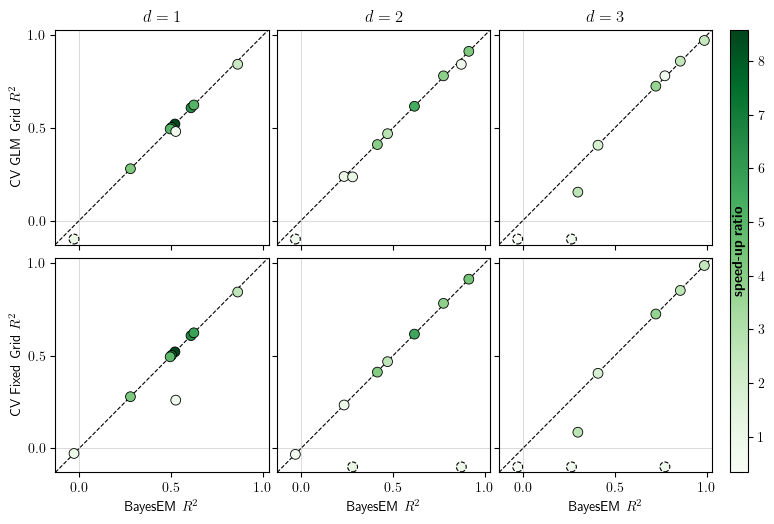

In [10]:
su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for e in [exp, exp_d2, exp_d3] for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, e in enumerate([exp, exp_d2, exp_d3]):
    for row, cv in enumerate([2, 1]):
        scatter_clipped(np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0),
                        np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0),
                        np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                        / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0),
                        norm, plt.cm.Greens, ax=axes[row, col])


## Full Experiment: Small and Moderately-sized Datasets

This experiment corresponds to Figure 3 of the appendix.

In [ ]:
exp_full = Experiment(
    JOURNAL2026_D1_REGULAR, JOURNAL2026_ESTIMATORS,
    reps=100, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D1_REGULAR],
    seed=123,
    est_names=JOURNAL2026_EST_NAMES).run(overwrite_cache=True)
print()

In [14]:
rows_full = []
for i, problem in enumerate(exp_full.problems):
    em_time = stat_mean(exp_full, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_full, 'prediction_r2', est, i) for est in exp_full.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full.ns[i, 0])
    row['n:p']            = int(exp_full.ns[i, 0]) / stat_mean(exp_full, 'number_of_features', 'EM', i)
    rows_full.append(row)
pd.DataFrame(rows_full).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
12,naval_propulsion,"GT_compressor_decay, GT_turbine_decay",0.88,0.88,0.88,9.48,15.00,8353,556.87
13,parkinsons,"motor_UPDRS, total_UPDRS",0.16,0.16,0.16,7.12,19.00,4112,216.42
0,abalone,Rings,0.53,0.53,0.53,8.58,9.00,2923,324.78
4,crime,ViolentCrimesPerPop,0.66,0.66,0.66,2.78,99.00,1395,14.09
1,airfoil,scaled-sound-pressure,0.51,0.51,0.51,7.94,5.00,1052,210.40
8,concrete,Concrete compressive strength,0.61,0.61,0.61,6.70,8.00,721,90.12
15,student,"G1, G2, G3",0.27,0.27,0.27,4.26,39.00,454,11.64
11,forest,area,-0.03,-0.04,-0.13,1.02,26.55,361,13.60
7,boston,medv,0.70,0.70,0.70,5.69,13.00,354,27.23
10,facebook,"comment, like, share",0.30,0.28,0.28,5.47,17.00,349,20.53


In [ ]:
exp_full_d2 = Experiment(
    JOURNAL2026_D2_REGULAR, JOURNAL2026_ESTIMATORS,
    reps=30, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D2_REGULAR],
    seed=123,
    est_names=JOURNAL2026_EST_NAMES).run(overwrite_cache=True)
print()

In [19]:
rows_full_d2 = []
for i, problem in enumerate(exp_full_d2.problems):
    em_time = stat_mean(exp_full_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_full_d2, 'prediction_r2', est, i) for est in exp_full_d2.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full_d2, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full_d2.ns[i, 0])
    row['n:p']            = int(exp_full_d2.ns[i, 0]) / stat_mean(exp_full_d2, 'number_of_features', 'EM', i)
    rows_full_d2.append(row)
pd.DataFrame(rows_full_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
11,naval_propulsion,"GT_compressor_decay, GT_turbine_decay",1.00,1.00,1.00,3.19,149.00,8353,56.06
12,parkinsons,"motor_UPDRS, total_UPDRS",0.24,0.23,0.23,2.93,209.00,4112,19.67
0,abalone,Rings,0.49,0.48,0.48,4.73,53.00,2923,55.15
4,crime,ViolentCrimesPerPop,0.67,-0.84,0.66,1.21,5049.00,1395,0.28
1,airfoil,scaled-sound-pressure,0.63,0.63,0.63,5.41,20.00,1052,52.60
7,concrete,Concrete compressive strength,0.78,0.78,0.78,4.23,44.00,721,16.39
14,student,"G1, G2, G3",0.28,-2.79,0.23,1.25,798.30,454,0.57
10,forest,area,-0.04,-0.04,-0.42,0.62,295.76,361,1.22
6,boston,medv,0.83,0.82,0.82,2.33,104.00,354,3.40
9,facebook,"comment, like, share",-5.12,-79.05,-30.42,1.87,166.97,349,2.09


In [ ]:
exp_full_d3 = Experiment(
    JOURNAL2026_D3_REGULAR, JOURNAL2026_ESTIMATORS,
    reps=30, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D3_REGULAR],
    seed=123,
    est_names=JOURNAL2026_EST_NAMES).run(overwrite_cache=True)
print()

In [23]:
rows_full_d3 = []
for i, problem in enumerate(exp_full_d3.problems):
    em_time = stat_mean(exp_full_d3, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full_d3, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full_d3, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_full_d3, 'prediction_r2', est, i) for est in exp_full_d3.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full_d3, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full_d3.ns[i, 0])
    row['n:p']            = int(exp_full_d3.ns[i, 0]) / stat_mean(exp_full_d3, 'number_of_features', 'EM', i)
    rows_full_d3.append(row)
pd.DataFrame(rows_full_d3).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
10,naval_propulsion,"GT_compressor_decay, GT_turbine_decay",1.00,1.00,1.00,2.67,963.00,8353,8.67
11,parkinsons,"motor_UPDRS, total_UPDRS",-1.37,-0.15,-0.19,1.88,1539.00,4112,2.67
0,abalone,Rings,0.47,0.37,0.39,2.88,209.00,2923,13.99
4,crime,ViolentCrimesPerPop,0.65,-0.20,0.57,1.04,25076.00,1395,0.06
1,airfoil,scaled-sound-pressure,0.73,0.73,0.73,3.75,55.00,1052,19.13
6,concrete,Concrete compressive strength,0.85,0.85,0.85,2.62,164.00,721,4.40
13,student,"G1, G2, G3",0.26,-0.55,-0.54,0.75,10529.53,454,0.04
9,forest,area,-0.04,-782.80,-1.12,0.34,1967.43,361,0.18
5,boston,medv,0.81,-160.26,0.81,1.59,559.00,354,0.63
8,facebook,"comment, like, share",-16.80,-144191.55,-52.14,1.00,1086.47,349,0.32


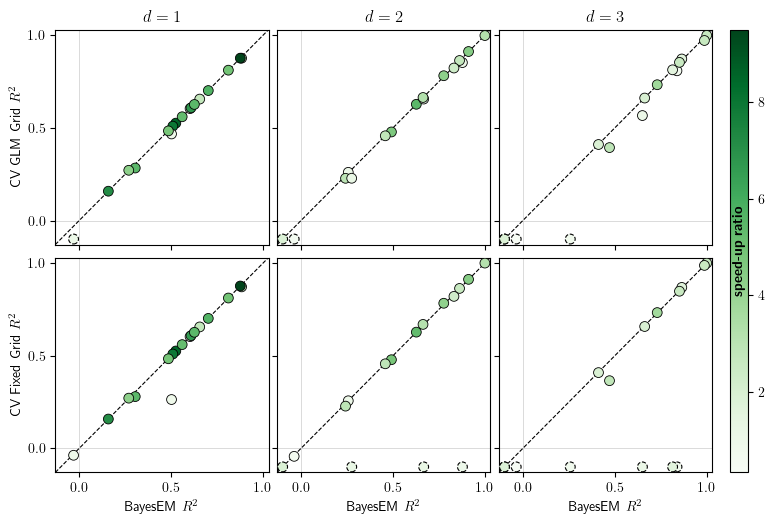

In [24]:
su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for e in [exp_full, exp_full_d2, exp_full_d3] for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, e in enumerate([exp_full, exp_full_d2, exp_full_d3]):
    for row, cv in enumerate([2, 1]):
        scatter_clipped(np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0),
                        np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0),
                        np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                        / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0),
                        norm, plt.cm.Greens, ax=axes[row, col])


In [ ]:
exp_large = Experiment(
    JOURNAL2026_D1_LARGE, JOURNAL2026_ESTIMATORS,
    reps=30, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D1_LARGE],
    seed=123,
    est_names=JOURNAL2026_EST_NAMES).run(overwrite_cache=True)
print()

In [27]:
rows_large = []
for i, problem in enumerate(exp_large.problems):
    em_time = stat_mean(exp_large, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_large, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_large, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_large, 'prediction_r2', est, i) for est in exp_large.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_large, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_large.ns[i, 0])
    row['n:p']            = int(exp_large.ns[i, 0]) / stat_mean(exp_large, 'number_of_features', 'EM', i)
    rows_large.append(row)
pd.DataFrame(rows_large).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,0.93,0.93,0.93,5.22,77.00,408275,5302.27
3,ct_slices,reference,0.86,0.86,0.86,3.85,379.53,37450,98.67
2,blog,V281,0.36,0.36,0.36,4.08,276.00,36677,132.89
1,tomshw,V97,0.96,0.96,0.96,3.65,96.00,19725,205.47


In [ ]:
exp_large_d2 = Experiment(
    JOURNAL2026_D2_LARGE, JOURNAL2026_ESTIMATORS,
    reps=30, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D2_LARGE],
    seed=123,
    est_names=JOURNAL2026_EST_NAMES).run(overwrite_cache=True)
print()

In [30]:
rows_large_d2 = []
for i, problem in enumerate(exp_large_d2.problems):
    em_time = stat_mean(exp_large_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_large_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_large_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_large_d2, 'prediction_r2', est, i) for est in exp_large_d2.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_large_d2, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_large_d2.ns[i, 0])
    row['n:p']            = int(exp_large_d2.ns[i, 0]) / stat_mean(exp_large_d2, 'number_of_features', 'EM', i)
    rows_large_d2.append(row)
pd.DataFrame(rows_large_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,0.91,0.91,0.91,5.39,86.00,408275,4747.38
3,ct_slices,reference,0.92,0.92,0.92,2.90,929.43,37450,40.29
2,blog,V281,-0.00,0.10,0.01,2.88,886.67,36677,41.37
1,tomshw,V97,0.92,0.96,0.96,2.03,1775.00,19725,11.11


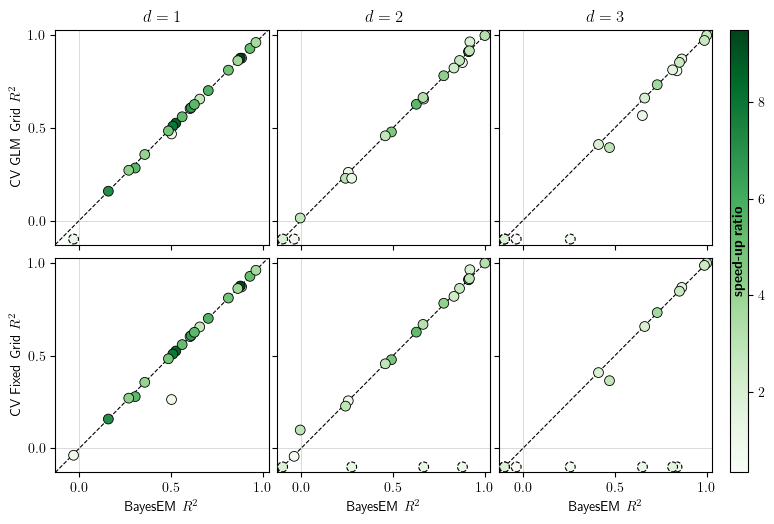

In [31]:
col_exps = [[exp_full, exp_large], [exp_full_d2, exp_large_d2], [exp_full_d3]]

su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for exps in col_exps for e in exps for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, exps in enumerate(col_exps):
    for row, cv in enumerate([2, 1]):
        scatter_clipped(
            np.concatenate([np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0) for e in exps]),
            np.concatenate([np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0) for e in exps]),
            np.concatenate([np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                            / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0) for e in exps]),
            norm, plt.cm.Greens, ax=axes[row, col])

fig.savefig('../output/realdata_r2_by_degree.pdf', bbox_inches='tight')
